In [64]:
import pandas as pd

data = {
    "year": [1990, 2020],
    "population": [1143, 1411],      # mil. obyvatel
    "gdp": [360, 14700],             # mld. USD
    "energy": [35, 145],             # EJ
    "co2": [2.4, 10.7]               # Gt CO2
}

df = pd.DataFrame(data)

df

,year,population,gdp,energy,co2
0,1990,1143,360,35,2.4
1,2020,1411,14700,145,10.7


In [65]:
url = "https://api.worldbank.org/v2/country/CHN/indicator/NY.GDP.MKTP.KD"

params = {
    "format": "json",
    "date": "1990:2024",
    "per_page": 100
}

response = requests.get(url, params=params)
data = response.json()[1]

gdp_real_wb = pd.DataFrame(data)

gdp_real_wb = gdp_real_wb[["date", "value"]].rename(columns={
    "date": "year",
    "value": "gdp_real_2015_usd"
})

gdp_real_wb["year"] = gdp_real_wb["year"].astype(int)
gdp_real_wb = gdp_real_wb.sort_values("year")

gdp_real_wb.head(), gdp_real_wb.tail()

(    year  gdp_real_2015_usd
 34  1990       1.041272e+12
 33  1991       1.138753e+12
 32  1992       1.301590e+12
 31  1993       1.482889e+12
 30  1994       1.676743e+12,
    year  gdp_real_2015_usd
 4  2020       1.492047e+13
 3  2021       1.619916e+13
 2  2022       1.670688e+13
 1  2023       1.761153e+13
 0  2024       1.848811e+13)

In [66]:
url = "https://api.worldbank.org/v2/country/CHN/indicator/SP.POP.TOTL"

params = {
    "format": "json",
    "date": "1990:2024",
    "per_page": 100
}

response = requests.get(url, params=params)
data = response.json()[1]

pop_wb = pd.DataFrame(data)

pop_wb = pop_wb[["date", "value"]].rename(columns={
    "date": "year",
    "value": "population"
})

pop_wb["year"] = pop_wb["year"].astype(int)
pop_wb = pop_wb.sort_values("year")

pop_wb.head(), pop_wb.tail()

(    year  population
 34  1990  1135185000
 33  1991  1150780000
 32  1992  1164970000
 31  1993  1178440000
 30  1994  1191835000,
    year  population
 4  2020  1411100000
 3  2021  1412360000
 2  2022  1412175000
 1  2023  1410710000
 0  2024  1408975000)

In [67]:
df = pd.merge(
    gdp_real_wb,
    pop_wb,
    on="year",
    how="inner"
)

df.head()

,year,gdp_real_2015_usd,population
0,1990,1.041272e+12,1135185000
1,1991,1.138753e+12,1150780000
2,1992,1.301590e+12,1164970000
3,1993,1.482889e+12,1178440000
4,1994,1.676743e+12,1191835000


In [68]:
df["gdp_per_capita"] = (
    df["gdp_real_2015_usd"] /
    df["population"]
)

df[["year", "gdp_per_capita"]].head()

,year,gdp_per_capita
0,1990,917.270662
1,1991,989.548541
2,1992,1117.273295
3,1993,1258.349461
4,1994,1406.858457


In [69]:
import pandas as pd

ei_file = "TES_EI.csv"

ei = pd.read_csv(ei_file)

ei.head()

,Country,Year,ISO3166_alpha3,ISO3166_numeric,Region,SubRegion,OPEC,EU,OECD,CIS,Var,Value
0,Algeria,1965,DZA,12.0,Africa,Northern Africa,1.0,0.0,0.0,0.0,biogeo_ej,0.000000
1,Algeria,1965,DZA,12.0,Africa,Northern Africa,1.0,0.0,0.0,0.0,co2_combust_mtco2,5.568753
2,Algeria,1965,DZA,12.0,Africa,Northern Africa,1.0,0.0,0.0,0.0,co2_combust_pc,0.007229
3,Algeria,1965,DZA,12.0,Africa,Northern Africa,1.0,0.0,0.0,0.0,co2_combust_per_ej,4.242345
4,Algeria,1965,DZA,12.0,Africa,Northern Africa,1.0,0.0,0.0,0.0,coalcons_ej,0.002931


In [70]:
ei["Var"].unique()

array(['biogeo_ej', 'co2_combust_mtco2', 'co2_combust_pc',
       'co2_combust_per_ej', 'coalcons_ej', 'gascons_bcfd', 'gascons_bcm',
       'gascons_ej', 'hydro_ej', 'hydro_twh', 'hydro_twh_net',
       'liqcons_kbd', 'nuclear_ej', 'nuclear_twh', 'nuclear_twh_net',
       'oilcons_ej', 'oilcons_kbd', 'oilcons_mt', 'oilprod_crudecond_kbd',
       'oilprod_kbd', 'oilprod_mt', 'oilprod_ngl_kbd', 'pop',
       'refcap_kbd', 'ren_power_ej', 'renewables_ej', 'solar_ej',
       'tes_ej', 'tes_gj_pc', 'wind_ej', 'gasprod_bcfd', 'gasprod_bcm',
       'gasprod_ej', 'gasflared_bcm', 'gasflared_mtco2', 'refcaputil_pct',
       'refthru_kbd', 'elect_twh', 'biogeo_twh', 'biogeo_twh_net',
       'co2_mtco2', 'methane_process_mtco2', 'ren_power_twh',
       'ren_power_twh_net', 'solar_twh', 'solar_twh_net', 'wind_twh',
       'wind_twh_net', 'electbyfuel_hydro', 'electbyfuel_nuclear',
       'electbyfuel_ren_power', 'electbyfuel_coal', 'electbyfuel_gas',
       'electbyfuel_oil', 'electbyfuel_other',

In [71]:
china_energy = ei[
    (ei["Country"] == "China") &
    (ei["Var"] == "tes_ej")
].copy()

china_energy = china_energy[["Year", "Value"]]

china_energy = china_energy.rename(columns={
    "Year": "year",
    "Value": "tes_ej"
})

china_energy.head(), china_energy.tail()

(       year    tes_ej
 32856  1965  5.374622
 32891  1966  5.851092
 32926  1967  5.267287
 32961  1968  5.298980
 32996  1969  6.478805,
        year      tes_ej
 36368  2020  137.978975
 36445  2021  145.234557
 36522  2022  146.558227
 36599  2023  154.684254
 36680  2024  158.883353)

In [72]:
df = pd.merge(
    gdp_real_wb,
    pop_wb,
    on="year",
    how="inner"
)

df = pd.merge(
    df,
    china_energy,
    on="year",
    how="inner"
)

df.head()

,year,gdp_real_2015_usd,population,tes_ej
0,1990,1.041272e+12,1135185000,27.686203
1,1991,1.138753e+12,1150780000,29.138333
2,1992,1.301590e+12,1164970000,30.666430
3,1993,1.482889e+12,1178440000,32.980124
4,1994,1.676743e+12,1191835000,35.006294


In [73]:
china_ei = ei[
    (ei["Country"] == "China") &
    (ei["Var"].isin(["tes_ej", "co2_combust_mtco2"]))
].copy()

china_ei = china_ei[["Year", "Var", "Value"]]

china_ei = china_ei.pivot(
    index="Year",
    columns="Var",
    values="Value"
).reset_index()

china_ei = china_ei.rename(columns={
    "Year": "year",
    "tes_ej": "energy_ej",
    "co2_combust_mtco2": "co2_mt"
})

china_ei.head(), china_ei.tail()

(Var  year      co2_mt  energy_ej
 0    1965  488.525414   5.374622
 1    1966  530.349057   5.851092
 2    1967  475.920690   5.267287
 3    1968  476.682791   5.298980
 4    1969  582.473714   6.478805,
 Var  year       co2_mt   energy_ej
 55   2020  10082.65729  137.978975
 56   2021  10470.89088  145.234557
 57   2022  10504.53398  146.558227
 58   2023  11007.45778  154.684254
 59   2024  11172.84560  158.883353)

In [74]:
df = pd.merge(gdp_real_wb, pop_wb, on="year", how="inner")
df = pd.merge(df, china_ei, on="year", how="inner")

df.head(), df.tail()

(   year  gdp_real_2015_usd  population       co2_mt  energy_ej
 0  1990       1.041272e+12  1135185000  2308.792723  27.686203
 1  1991       1.138753e+12  1150780000  2439.954363  29.138333
 2  1992       1.301590e+12  1164970000  2562.756190  30.666430
 3  1993       1.482889e+12  1178440000  2769.614442  32.980124
 4  1994       1.676743e+12  1191835000  2921.357668  35.006294,
     year  gdp_real_2015_usd  population       co2_mt   energy_ej
 30  2020       1.492047e+13  1411100000  10082.65729  137.978975
 31  2021       1.619916e+13  1412360000  10470.89088  145.234557
 32  2022       1.670688e+13  1412175000  10504.53398  146.558227
 33  2023       1.761153e+13  1410710000  11007.45778  154.684254
 34  2024       1.848811e+13  1408975000  11172.84560  158.883353)

In [75]:
df["gdp_per_capita"] = df["gdp_real_2015_usd"] / df["population"]

df["energy_intensity"] = df["energy_ej"] / df["gdp_real_2015_usd"]

df["carbon_intensity"] = df["co2_mt"] / df["energy_ej"]

df[[
    "year",
    "population",
    "gdp_real_2015_usd",
    "energy_ej",
    "co2_mt",
    "gdp_per_capita",
    "energy_intensity",
    "carbon_intensity"
]].head()

,year,population,gdp_real_2015_usd,energy_ej,co2_mt,gdp_per_capita,energy_intensity,carbon_intensity
0,1990,1135185000,1.041272e+12,27.686203,2308.792723,917.270662,2.658883e-11,83.391453
1,1991,1150780000,1.138753e+12,29.138333,2439.954363,989.548541,2.558794e-11,83.736924
2,1992,1164970000,1.301590e+12,30.666430,2562.756190,1117.273295,2.356075e-11,83.568782
3,1993,1178440000,1.482889e+12,32.980124,2769.614442,1258.349461,2.224045e-11,83.978290
4,1994,1191835000,1.676743e+12,35.006294,2921.357668,1406.858457,2.087755e-11,83.452354


In [76]:
df["co2_check"] = (
    df["population"] *
    df["gdp_per_capita"] *
    df["energy_intensity"] *
    df["carbon_intensity"]
)

df[["year", "co2_mt", "co2_check"]].head()

,year,co2_mt,co2_check
0,1990,2308.792723,2308.792723
1,1991,2439.954363,2439.954363
2,1992,2562.756190,2562.756190
3,1993,2769.614442,2769.614442
4,1994,2921.357668,2921.357668


In [77]:
df[["year", "co2_mt", "co2_check"]].tail()

,year,co2_mt,co2_check
30,2020,10082.65729,10082.65729
31,2021,10470.89088,10470.89088
32,2022,10504.53398,10504.53398
33,2023,11007.45778,11007.45778
34,2024,11172.84560,11172.84560


In [78]:
start_year = 1990
end_year = 2024

d = df[df["year"].isin([start_year, end_year])].copy()

d[[
    "year",
    "population",
    "gdp_per_capita",
    "energy_intensity",
    "carbon_intensity",
    "co2_mt"
]]

,year,population,gdp_per_capita,energy_intensity,carbon_intensity,co2_mt
0,1990,1135185000,917.270662,2.658883e-11,83.391453,2308.792723
34,2024,1408975000,13121.676991,8.593810e-12,70.321059,11172.845600


In [79]:
import numpy as np

row0 = d[d["year"] == start_year].iloc[0]
row1 = d[d["year"] == end_year].iloc[0]

C0 = row0["co2_mt"]
C1 = row1["co2_mt"]

L = (C1 - C0) / (np.log(C1) - np.log(C0))

effects = {
    "population_effect": L * np.log(row1["population"] / row0["population"]),
    "gdp_per_capita_effect": L * np.log(row1["gdp_per_capita"] / row0["gdp_per_capita"]),
    "energy_intensity_effect": L * np.log(row1["energy_intensity"] / row0["energy_intensity"]),
    "carbon_intensity_effect": L * np.log(row1["carbon_intensity"] / row0["carbon_intensity"]),
}

effects_df = pd.DataFrame.from_dict(effects, orient="index", columns=["change_mtco2"])
effects_df

,change_mtco2
population_effect,1214.659254
gdp_per_capita_effect,14957.151102
energy_intensity_effect,-6349.403915
carbon_intensity_effect,-958.353563


In [80]:
total_change = C1 - C0
sum_effects = effects_df["change_mtco2"].sum()

print("Celková změna emisí:", total_change)
print("Součet efektů:", sum_effects)
print("Rozdíl:", total_change - sum_effects)

Celková změna emisí: 8864.052877
Součet efektů: 8864.052877
Rozdíl: 0.0


In [81]:
effects_df["change_gtco2"] = effects_df["change_mtco2"] / 1000
effects_df["share_percent"] = effects_df["change_mtco2"] / total_change * 100

effects_df

,change_mtco2,change_gtco2,share_percent
population_effect,1214.659254,1.214659,13.703204
gdp_per_capita_effect,14957.151102,14.957151,168.739416
energy_intensity_effect,-6349.403915,-6.349404,-71.630935
carbon_intensity_effect,-958.353563,-0.958354,-10.811686


In [82]:
# Seřadíme roky
df = df.sort_values("year").copy()

# Vybereme období
kaya = df[(df["year"] >= 1990) & (df["year"] <= 2024)].copy()

# Meziroční logaritmické změny v %
kaya["population_pp"] = 100 * np.log(kaya["population"] / kaya["population"].shift(1))
kaya["gdp_per_capita_pp"] = 100 * np.log(kaya["gdp_per_capita"] / kaya["gdp_per_capita"].shift(1))
kaya["energy_intensity_pp"] = 100 * np.log(kaya["energy_intensity"] / kaya["energy_intensity"].shift(1))
kaya["carbon_intensity_pp"] = 100 * np.log(kaya["carbon_intensity"] / kaya["carbon_intensity"].shift(1))

# Skutečná meziroční změna emisí CO2 v %
kaya["co2_growth_pct"] = 100 * np.log(kaya["co2_mt"] / kaya["co2_mt"].shift(1))

# Kontrola: součet faktorů by měl sedět na změnu CO2
kaya["sum_factors"] = (
    kaya["population_pp"] +
    kaya["gdp_per_capita_pp"] +
    kaya["energy_intensity_pp"] +
    kaya["carbon_intensity_pp"]
)

kaya[[
    "year",
    "co2_growth_pct",
    "sum_factors",
    "population_pp",
    "gdp_per_capita_pp",
    "energy_intensity_pp",
    "carbon_intensity_pp"
]].head(10)

,year,co2_growth_pct,sum_factors,population_pp,gdp_per_capita_pp,energy_intensity_pp,carbon_intensity_pp
0,1990,NaN,NaN,NaN,NaN,NaN,NaN
1,1991,5.525458,5.525458,1.364434,7.584623,-3.837020,0.413421
2,1992,4.910398,4.910398,1.225536,12.139762,-8.253900,-0.201000
3,1993,7.762480,7.762480,1.149619,11.890975,-5.766942,0.488828
4,1994,5.334034,5.334034,1.130261,11.155826,-6.323808,-0.628245
5,1995,2.961364,2.961364,1.086509,9.379049,-7.853949,0.349756
6,1996,4.785083,4.785083,1.048142,8.461238,-4.036956,-0.687340
7,1997,-0.454791,-0.454791,1.023450,7.857868,-8.336227,-0.999882
8,1998,-0.080340,-0.080340,0.959550,6.663186,-7.496395,-0.206682
9,1999,4.016159,4.016159,0.865851,6.586440,-3.844227,0.408094


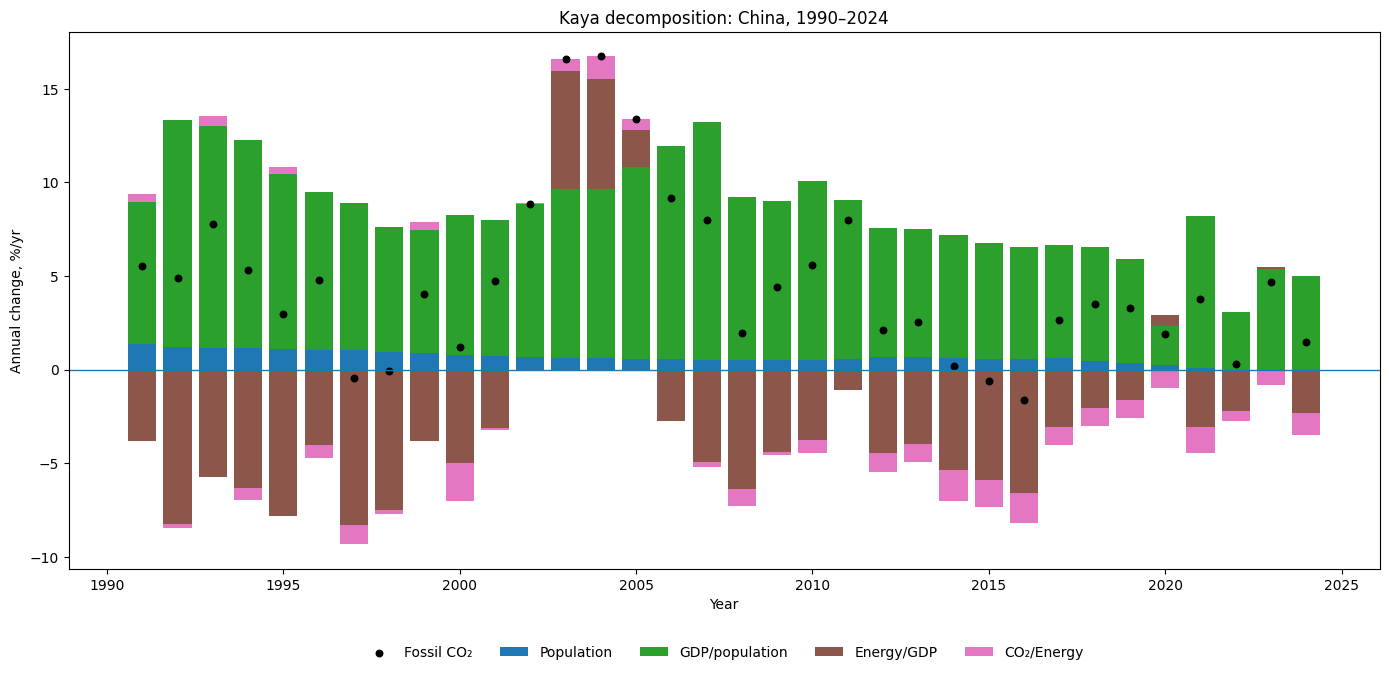

In [102]:
import matplotlib.pyplot as plt
import numpy as np

plot = kaya.dropna().copy()

fig, ax = plt.subplots(figsize=(14, 7))

bottom_pos = np.zeros(len(plot))
bottom_neg = np.zeros(len(plot))

components = [
    ("population_pp", "Population", "tab:blue"),
    ("gdp_per_capita_pp", "GDP/population", "tab:green"),
    ("energy_intensity_pp", "Energy/GDP", "tab:brown"),
    ("carbon_intensity_pp", "CO₂/Energy", "tab:pink")
]

for col, label, color in components:
    values = plot[col].values
    pos = np.where(values > 0, values, 0)
    neg = np.where(values < 0, values, 0)

    ax.bar(plot["year"], pos, bottom=bottom_pos, label=label, color=color)
    ax.bar(plot["year"], neg, bottom=bottom_neg, color=color)

    bottom_pos += pos
    bottom_neg += neg

ax.scatter(
    plot["year"],
    plot["co2_growth_pct"],
    color="black",
    s=22,
    label="Fossil CO₂"
)

ax.axhline(0, linewidth=1)

ax.set_title("Kaya decomposition: China, 1990–2024")
ax.set_ylabel("Annual change, %/yr")
ax.set_xlabel("Year")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    frameon=False
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.savefig(
    "china_kaya_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.show()

In [84]:
kaya.loc[
    kaya["year"].between(2001, 2006),
    [
        "year",
        "co2_growth_pct",
        "population_pp",
        "gdp_per_capita_pp",
        "energy_intensity_pp",
        "carbon_intensity_pp",
        "sum_factors"
    ]
]

,year,co2_growth_pct,population_pp,gdp_per_capita_pp,energy_intensity_pp,carbon_intensity_pp,sum_factors
11,2001,4.754083,0.726381,7.258786,-3.112293,-0.118790,4.754083
12,2002,8.867297,0.670000,8.170818,-0.045369,0.071849,8.867297
13,2003,16.602471,0.622861,9.015547,6.330129,0.633934,16.602471
14,2004,16.745690,0.593933,9.056475,5.866368,1.228914,16.745690
15,2005,13.371804,0.588125,10.259854,1.978044,0.545781,13.371804
16,2006,9.171599,0.558374,11.375076,-2.739301,-0.022549,9.171599


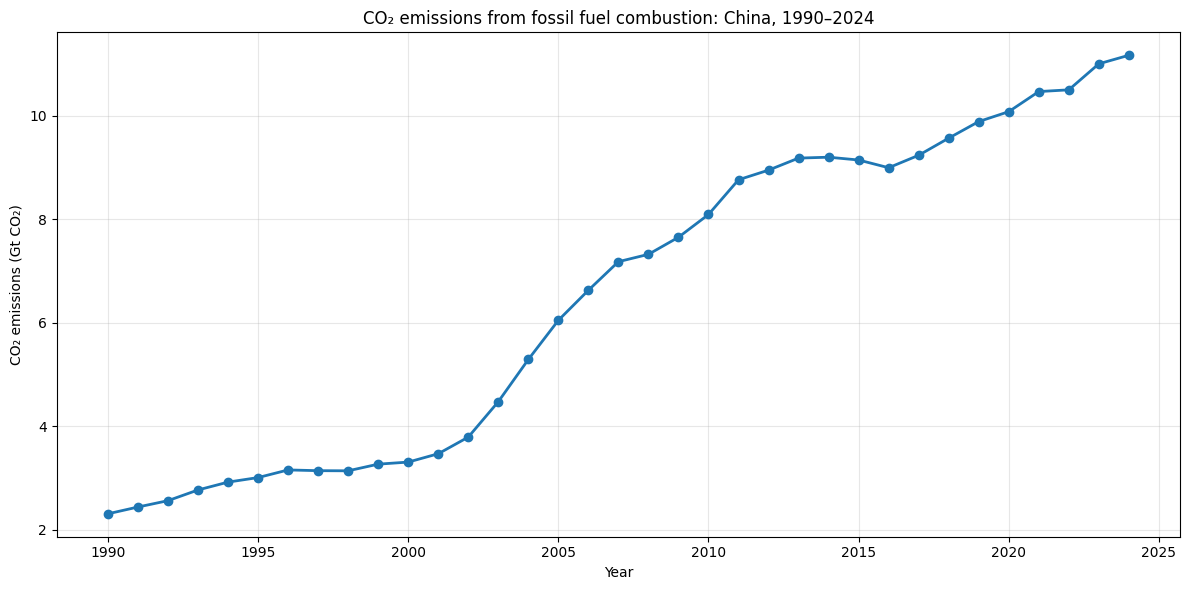

In [85]:
co2_plot = kaya[["year", "co2_mt"]].dropna().copy()
co2_plot["co2_gt"] = co2_plot["co2_mt"] / 1000

plt.figure(figsize=(12, 6))

plt.plot(
    co2_plot["year"],
    co2_plot["co2_gt"],
    marker="o",
    linewidth=2
)

plt.title("CO₂ emissions from fossil fuel combustion: China, 1990–2024")
plt.xlabel("Year")
plt.ylabel("CO₂ emissions (Gt CO₂)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [86]:
[c for c in sorted(ei["Country"].unique()) if "US" in c or "America" in c or "States" in c]

['Other North America',
 'Other S. & Cent. America',
 'Other South America',
 'Total Central America',
 'Total North America',
 'Total S. & Cent. America',
 'US',
 'USSR']

In [87]:
country_name = "US"
country_code_wb = "USA"

In [88]:
usa_ei = ei[
    (ei["Country"] == country_name) &
    (ei["Var"].isin(["tes_ej", "co2_combust_mtco2"]))
].copy()

usa_ei[["Country", "Year", "Var", "Value"]].head(10)

,Country,Year,Var,Value
279998,US,1965,co2_combust_mtco2,3451.891864
280033,US,1965,tes_ej,50.581347
280039,US,1966,co2_combust_mtco2,3639.794981
280074,US,1966,tes_ej,53.483057
280080,US,1967,co2_combust_mtco2,3738.161259
280115,US,1967,tes_ej,55.208237
280121,US,1968,co2_combust_mtco2,3947.343514
280156,US,1968,tes_ej,58.594754
280162,US,1969,co2_combust_mtco2,4117.396218
280197,US,1969,tes_ej,61.514629


In [89]:
usa_ei = usa_ei.pivot(
    index="Year",
    columns="Var",
    values="Value"
).reset_index()

usa_ei.head()

Var,Year,co2_combust_mtco2,tes_ej
0,1965,3451.891864,50.581347
1,1966,3639.794981,53.483057
2,1967,3738.161259,55.208237
3,1968,3947.343514,58.594754
4,1969,4117.396218,61.514629


In [90]:
usa_ei = usa_ei.rename(columns={
    "Year": "year",
    "tes_ej": "energy_ej",
    "co2_combust_mtco2": "co2_mt"
})

usa_ei.head()

Var,year,co2_mt,energy_ej
0,1965,3451.891864,50.581347
1,1966,3639.794981,53.483057
2,1967,3738.161259,55.208237
3,1968,3947.343514,58.594754
4,1969,4117.396218,61.514629


In [91]:
usa_ei.columns.tolist()

['year', 'co2_mt', 'energy_ej']

In [92]:
['year', 'co2_mt', 'energy_ej']

['year', 'co2_mt', 'energy_ej']

In [93]:
country_code_wb = "USA"

url = f"https://api.worldbank.org/v2/country/{country_code_wb}/indicator/NY.GDP.MKTP.KD"

params = {
    "format": "json",
    "date": "1990:2024",
    "per_page": 100
}

response = requests.get(url, params=params)
data = response.json()[1]

gdp_real_usa = pd.DataFrame(data)

gdp_real_usa = gdp_real_usa[["date", "value"]].rename(columns={
    "date": "year",
    "value": "gdp_real_2015_usd"
})

gdp_real_usa["year"] = gdp_real_usa["year"].astype(int)
gdp_real_usa = gdp_real_usa.sort_values("year")

gdp_real_usa.head(), gdp_real_usa.tail()

(    year  gdp_real_2015_usd
 34  1990       9.737637e+12
 33  1991       9.727089e+12
 32  1992       1.006973e+13
 31  1993       1.034682e+13
 30  1994       1.076370e+13,
    year  gdp_real_2015_usd
 4  2020       1.962763e+13
 3  2021       2.081610e+13
 2  2022       2.133907e+13
 1  2023       2.195525e+13
 0  2024       2.256846e+13)

In [94]:
url = f"https://api.worldbank.org/v2/country/{country_code_wb}/indicator/SP.POP.TOTL"

response = requests.get(url, params=params)
data = response.json()[1]

pop_usa = pd.DataFrame(data)

pop_usa = pop_usa[["date", "value"]].rename(columns={
    "date": "year",
    "value": "population"
})

pop_usa["year"] = pop_usa["year"].astype(int)
pop_usa = pop_usa.sort_values("year")

pop_usa.head(), pop_usa.tail()

(    year  population
 34  1990   249623000
 33  1991   252981000
 32  1992   256514000
 31  1993   259919000
 30  1994   263126000,
    year  population
 4  2020   331577720
 3  2021   332099760
 2  2022   334017321
 1  2023   336806231
 0  2024   340110988)

In [95]:
usa = pd.merge(gdp_real_usa, pop_usa, on="year", how="inner")
usa = pd.merge(usa, usa_ei, on="year", how="inner")

usa = usa.sort_values("year").copy()

usa.head(), usa.tail()

(   year  gdp_real_2015_usd  population       co2_mt  energy_ej
 0  1990       9.737637e+12   249623000  4971.209525  80.127813
 1  1991       9.727089e+12   252981000  4923.568110  80.093747
 2  1992       1.006973e+13   256514000  5005.970740  81.554633
 3  1993       1.034682e+13   259919000  5119.325964  83.107709
 4  1994       1.076370e+13   263126000  5196.431493  84.772104,
     year  gdp_real_2015_usd  population       co2_mt  energy_ej
 30  2020       1.962763e+13   331577720  4468.372662  86.213756
 31  2021       2.081610e+13   332099760  4755.310256  90.785549
 32  2022       2.133907e+13   334017321  4801.927576  92.251548
 33  2023       2.195525e+13   336806231  4642.749416  91.197763
 34  2024       2.256846e+13   340110988  4619.121942  91.832112)

In [96]:
usa["gdp_per_capita"] = usa["gdp_real_2015_usd"] / usa["population"]
usa["energy_intensity"] = usa["energy_ej"] / usa["gdp_real_2015_usd"]
usa["carbon_intensity"] = usa["co2_mt"] / usa["energy_ej"]

usa[[
    "year",
    "population",
    "gdp_per_capita",
    "energy_intensity",
    "carbon_intensity",
    "co2_mt"
]].head()

,year,population,gdp_per_capita,energy_intensity,carbon_intensity,co2_mt
0,1990,249623000,39009.372508,8.228672e-12,62.040998,4971.209525
1,1991,252981000,38449.881528,8.234092e-12,61.472566,4923.568110
2,1992,256514000,39256.048133,8.098992e-12,61.381807,5005.970740
3,1993,259919000,39807.879503,8.032195e-12,61.598690,5119.325964
4,1994,263126000,40907.018435,7.875740e-12,61.298838,5196.431493


In [97]:
usa_kaya = usa[(usa["year"] >= 1990) & (usa["year"] <= 2024)].copy()

usa_kaya["population_pp"] = 100 * np.log(usa_kaya["population"] / usa_kaya["population"].shift(1))
usa_kaya["gdp_per_capita_pp"] = 100 * np.log(usa_kaya["gdp_per_capita"] / usa_kaya["gdp_per_capita"].shift(1))
usa_kaya["energy_intensity_pp"] = 100 * np.log(usa_kaya["energy_intensity"] / usa_kaya["energy_intensity"].shift(1))
usa_kaya["carbon_intensity_pp"] = 100 * np.log(usa_kaya["carbon_intensity"] / usa_kaya["carbon_intensity"].shift(1))

usa_kaya["co2_growth_pct"] = 100 * np.log(usa_kaya["co2_mt"] / usa_kaya["co2_mt"].shift(1))

usa_kaya["sum_factors"] = (
    usa_kaya["population_pp"] +
    usa_kaya["gdp_per_capita_pp"] +
    usa_kaya["energy_intensity_pp"] +
    usa_kaya["carbon_intensity_pp"]
)

usa_kaya[[
    "year",
    "co2_growth_pct",
    "sum_factors",
    "population_pp",
    "gdp_per_capita_pp",
    "energy_intensity_pp",
    "carbon_intensity_pp"
]].head(10)

,year,co2_growth_pct,sum_factors,population_pp,gdp_per_capita_pp,energy_intensity_pp,carbon_intensity_pp
0,1990,NaN,NaN,NaN,NaN,NaN,NaN
1,1991,-0.962968,-0.962968,1.336261,-1.444632,0.065847,-0.920444
2,1992,1.659785,1.659785,1.386886,2.074991,-1.654341,-0.147750
3,1993,2.239143,2.239143,1.318680,1.395935,-0.828182,0.352710
4,1994,1.494936,1.494936,1.226296,2.723678,-1.967068,-0.487971
5,1995,0.616980,0.616980,1.190787,1.458245,-0.927654,-1.104398
6,1996,3.387544,3.387544,1.163412,2.539933,-0.588276,0.272476
7,1997,1.383495,1.383495,1.203960,3.147120,-3.682875,0.715290
8,1998,0.731866,0.731866,1.165715,3.219832,-3.442844,-0.210837
9,1999,0.896561,0.896561,1.148340,3.528973,-2.819741,-0.961011


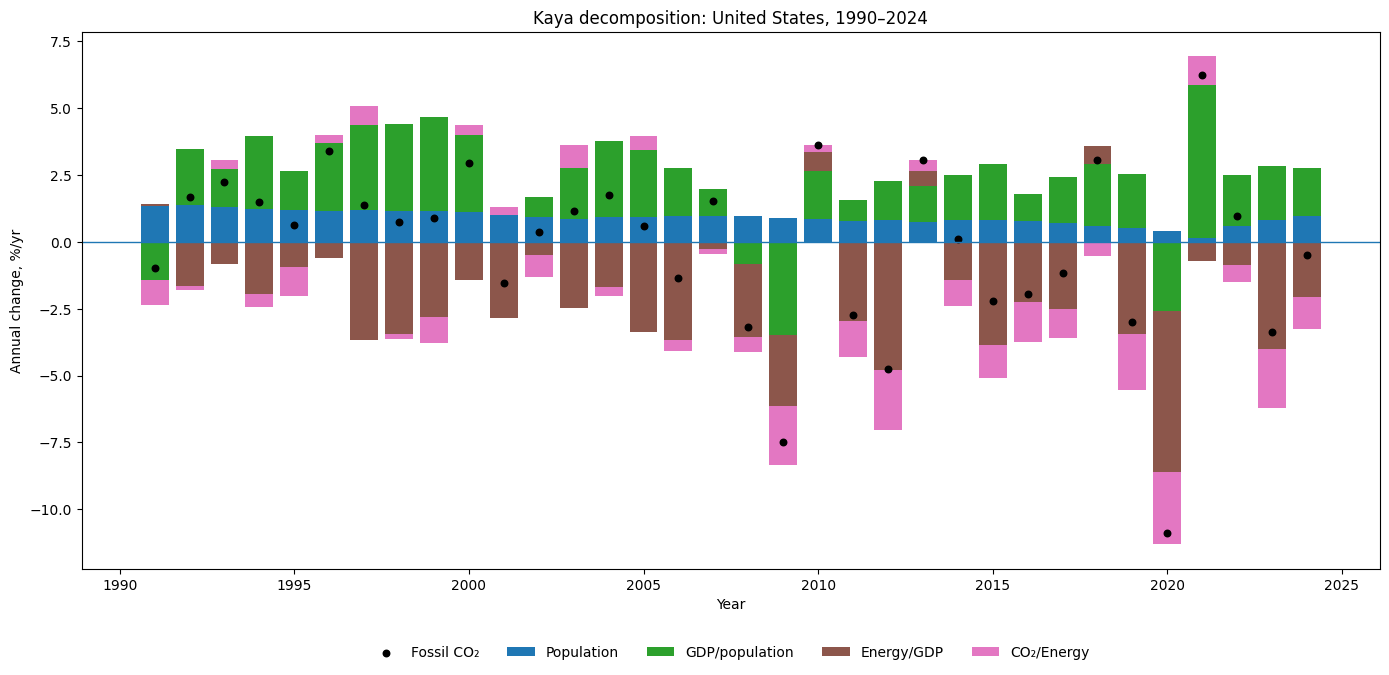

In [103]:
plot = usa_kaya.dropna().copy()

fig, ax = plt.subplots(figsize=(14, 7))

bottom_pos = np.zeros(len(plot))
bottom_neg = np.zeros(len(plot))

components = [
    ("population_pp", "Population", "tab:blue"),
    ("gdp_per_capita_pp", "GDP/population", "tab:green"),
    ("energy_intensity_pp", "Energy/GDP", "tab:brown"),
    ("carbon_intensity_pp", "CO₂/Energy", "tab:pink")
]

for col, label, color in components:
    values = plot[col].values
    pos = np.where(values > 0, values, 0)
    neg = np.where(values < 0, values, 0)

    ax.bar(plot["year"], pos, bottom=bottom_pos, label=label, color=color)
    ax.bar(plot["year"], neg, bottom=bottom_neg, color=color)

    bottom_pos += pos
    bottom_neg += neg

ax.scatter(
    plot["year"],
    plot["co2_growth_pct"],
    color="black",
    s=22,
    label="Fossil CO₂"
)

ax.axhline(0, linewidth=1)

ax.set_title("Kaya decomposition: United States, 1990–2024")
ax.set_ylabel("Annual change, %/yr")
ax.set_xlabel("Year")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    frameon=False
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.savefig(
    "usa_kaya_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.show()

In [99]:
kaya.to_csv("china_kaya_1990_2024.csv", index=False)
usa_kaya.to_csv("usa_kaya_1990_2024.csv", index=False)
usa.to_csv("usa_full_dataset.csv", index=False)
df.to_csv("china_full_dataset.csv", index=False)

In [100]:
from google.colab import files

files.download("china_kaya_1990_2024.csv")
files.download("usa_kaya_1990_2024.csv")
files.download("china_full_dataset.csv")
files.download("usa_full_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [101]:
from google.colab import files

files.download("china_kaya_1990_2024.csv")
files.download("usa_kaya_1990_2024.csv")
files.download("china_full_dataset.csv")
files.download("usa_full_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [104]:
import os

os.listdir()

['.config',
 'usa_full_dataset.csv',
 'figures',
 'usa_kaya_decomposition.png',
 'TES_IEA.csv',
 '.ipynb_checkpoints',
 'usa_kaya_1990_2024.csv',
 'china_full_dataset.csv',
 'china_kaya_decomposition.png',
 'data_processed',
 'data_raw',
 'TES_EI.csv',
 'china_kaya_1990_2024.csv',
 'sample_data']

In [105]:
country_name = "United Kingdom"
country_code_wb = "GBR"

In [106]:
country_name = "United Kingdom"

uk_ei = ei[
    (ei["Country"] == country_name) &
    (ei["Var"].isin(["tes_ej", "co2_combust_mtco2"]))
].copy()

uk_ei[["Country", "Year", "Var", "Value"]].head(10)

,Country,Year,Var,Value
276616,United Kingdom,1965,co2_combust_mtco2,688.098035
276648,United Kingdom,1965,tes_ej,8.316421
276656,United Kingdom,1966,co2_combust_mtco2,680.946946
276688,United Kingdom,1966,tes_ej,8.361074
276696,United Kingdom,1967,co2_combust_mtco2,670.097427
276728,United Kingdom,1967,tes_ej,8.363311
276736,United Kingdom,1968,co2_combust_mtco2,689.743000
276768,United Kingdom,1968,tes_ej,8.673082
276776,United Kingdom,1969,co2_combust_mtco2,707.625731
276809,United Kingdom,1969,tes_ej,8.992704


In [107]:
uk_ei = uk_ei.pivot(
    index="Year",
    columns="Var",
    values="Value"
).reset_index()

uk_ei = uk_ei.rename(columns={
    "Year": "year",
    "tes_ej": "energy_ej",
    "co2_combust_mtco2": "co2_mt"
})

uk_ei.head()

Var,year,co2_mt,energy_ej
0,1965,688.098035,8.316421
1,1966,680.946946,8.361074
2,1967,670.097427,8.363311
3,1968,689.743000,8.673082
4,1969,707.625731,8.992704


In [108]:
country_code_wb = "GBR"

url = f"https://api.worldbank.org/v2/country/{country_code_wb}/indicator/NY.GDP.MKTP.KD"

params = {
    "format": "json",
    "date": "1990:2024",
    "per_page": 100
}

response = requests.get(url, params=params)
data = response.json()[1]

gdp_real_uk = pd.DataFrame(data)

gdp_real_uk = gdp_real_uk[["date", "value"]].rename(columns={
    "date": "year",
    "value": "gdp_real_2015_usd"
})

gdp_real_uk["year"] = gdp_real_uk["year"].astype(int)
gdp_real_uk = gdp_real_uk.sort_values("year")

gdp_real_uk.head(), gdp_real_uk.tail()

(    year  gdp_real_2015_usd
 34  1990       1.721504e+12
 33  1991       1.699255e+12
 32  1992       1.721255e+12
 31  1993       1.781336e+12
 30  1994       1.869573e+12,
    year  gdp_real_2015_usd
 4  2020       2.868822e+12
 3  2021       3.113908e+12
 2  2022       3.274265e+12
 1  2023       3.283160e+12
 0  2024       3.320142e+12)

In [109]:
url = f"https://api.worldbank.org/v2/country/{country_code_wb}/indicator/SP.POP.TOTL"

response = requests.get(url, params=params)
data = response.json()[1]

pop_uk = pd.DataFrame(data)

pop_uk = pop_uk[["date", "value"]].rename(columns={
    "date": "year",
    "value": "population"
})

pop_uk["year"] = pop_uk["year"].astype(int)
pop_uk = pop_uk.sort_values("year")

pop_uk.head(), pop_uk.tail()

(    year  population
 34  1990    57247586
 33  1991    57424897
 32  1992    57580402
 31  1993    57718614
 30  1994    57865745,
    year  population
 4  2020    66744000
 3  2021    66984000
 2  2022    67604000
 1  2023    68492000
 0  2024    69226000)

In [110]:
uk = pd.merge(gdp_real_uk, pop_uk, on="year", how="inner")
uk = pd.merge(uk, uk_ei, on="year", how="inner")
uk = uk.sort_values("year").copy()

uk["gdp_per_capita"] = uk["gdp_real_2015_usd"] / uk["population"]
uk["energy_intensity"] = uk["energy_ej"] / uk["gdp_real_2015_usd"]
uk["carbon_intensity"] = uk["co2_mt"] / uk["energy_ej"]

uk_kaya = uk[(uk["year"] >= 1990) & (uk["year"] <= 2024)].copy()

uk_kaya["population_pp"] = 100 * np.log(uk_kaya["population"] / uk_kaya["population"].shift(1))
uk_kaya["gdp_per_capita_pp"] = 100 * np.log(uk_kaya["gdp_per_capita"] / uk_kaya["gdp_per_capita"].shift(1))
uk_kaya["energy_intensity_pp"] = 100 * np.log(uk_kaya["energy_intensity"] / uk_kaya["energy_intensity"].shift(1))
uk_kaya["carbon_intensity_pp"] = 100 * np.log(uk_kaya["carbon_intensity"] / uk_kaya["carbon_intensity"].shift(1))

uk_kaya["co2_growth_pct"] = 100 * np.log(uk_kaya["co2_mt"] / uk_kaya["co2_mt"].shift(1))

uk_kaya["sum_factors"] = (
    uk_kaya["population_pp"] +
    uk_kaya["gdp_per_capita_pp"] +
    uk_kaya["energy_intensity_pp"] +
    uk_kaya["carbon_intensity_pp"]
)

uk_kaya[[
    "year",
    "co2_growth_pct",
    "sum_factors",
    "population_pp",
    "gdp_per_capita_pp",
    "energy_intensity_pp",
    "carbon_intensity_pp"
]].head(10)

,year,co2_growth_pct,sum_factors,population_pp,gdp_per_capita_pp,energy_intensity_pp,carbon_intensity_pp
0,1990,NaN,NaN,NaN,NaN,NaN,NaN
1,1991,1.715999,1.715999,0.309248,-1.610112,3.462587,-0.445724
2,1992,-2.831299,-2.831299,0.270431,1.015987,-1.926143,-2.191575
3,1993,-2.398632,-2.398632,0.239745,3.191206,-2.126975,-3.702608
4,1994,-2.335433,-2.335433,0.254586,4.580050,-6.120580,-1.049490
5,1995,-0.457914,-0.457914,0.264547,3.207852,-3.094657,-0.835656
6,1996,3.615281,3.615281,0.254626,2.326685,2.264792,-1.230823
7,1997,-3.426780,-3.426780,0.257553,4.507098,-6.566776,-1.624656
8,1998,0.069497,0.069497,0.291406,2.903329,-2.440897,-0.684341
9,1999,-1.653464,-1.653464,0.333406,2.568536,-3.420055,-1.135351


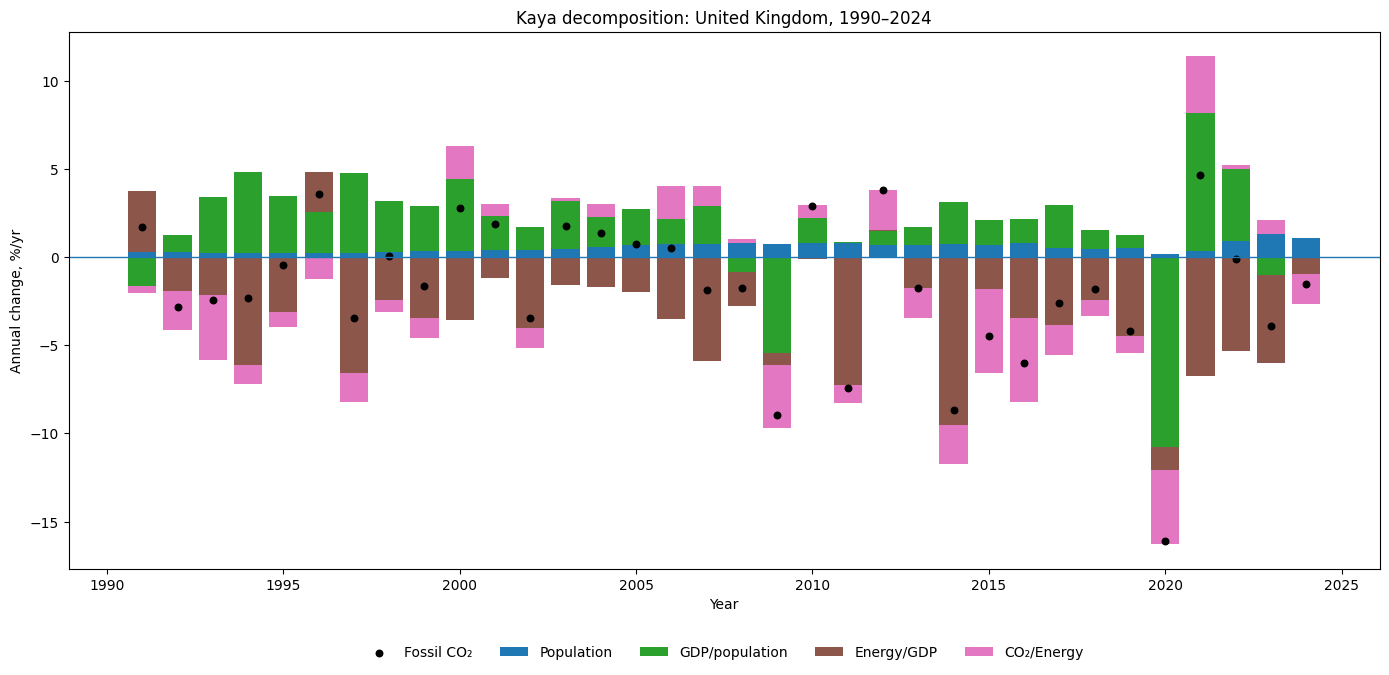

In [111]:
plot = uk_kaya.dropna().copy()

fig, ax = plt.subplots(figsize=(14, 7))

bottom_pos = np.zeros(len(plot))
bottom_neg = np.zeros(len(plot))

components = [
    ("population_pp", "Population", "tab:blue"),
    ("gdp_per_capita_pp", "GDP/population", "tab:green"),
    ("energy_intensity_pp", "Energy/GDP", "tab:brown"),
    ("carbon_intensity_pp", "CO₂/Energy", "tab:pink")
]

for col, label, color in components:
    values = plot[col].values
    pos = np.where(values > 0, values, 0)
    neg = np.where(values < 0, values, 0)

    ax.bar(plot["year"], pos, bottom=bottom_pos, label=label, color=color)
    ax.bar(plot["year"], neg, bottom=bottom_neg, color=color)

    bottom_pos += pos
    bottom_neg += neg

ax.scatter(
    plot["year"],
    plot["co2_growth_pct"],
    color="black",
    s=22,
    label="Fossil CO₂"
)

ax.axhline(0, linewidth=1)

ax.set_title("Kaya decomposition: United Kingdom, 1990–2024")
ax.set_ylabel("Annual change, %/yr")
ax.set_xlabel("Year")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    frameon=False
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)

plt.savefig(
    "uk_kaya_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [112]:
country_name = "Germany"
country_code_wb = "DEU"

In [113]:
country_name = "Germany"

germany_ei = ei[
    (ei["Country"] == country_name) &
    (ei["Var"].isin(["tes_ej", "co2_combust_mtco2"]))
].copy()

germany_ei[["Country", "Year", "Var", "Value"]].head(10)

,Country,Year,Var,Value
61074,Germany,1965,co2_combust_mtco2,910.413862
61098,Germany,1965,tes_ej,10.575319
61102,Germany,1966,co2_combust_mtco2,901.037825
61126,Germany,1966,tes_ej,10.593859
61130,Germany,1967,co2_combust_mtco2,892.416100
61154,Germany,1967,tes_ej,10.573485
61158,Germany,1968,co2_combust_mtco2,944.755407
61182,Germany,1968,tes_ej,11.295655
61186,Germany,1969,co2_combust_mtco2,1011.924353
61210,Germany,1969,tes_ej,12.218014


In [114]:
germany_ei = germany_ei.pivot(
    index="Year",
    columns="Var",
    values="Value"
).reset_index()

germany_ei = germany_ei.rename(columns={
    "Year": "year",
    "tes_ej": "energy_ej",
    "co2_combust_mtco2": "co2_mt"
})

germany_ei.head()

Var,year,co2_mt,energy_ej
0,1965,910.413862,10.575319
1,1966,901.037825,10.593859
2,1967,892.416100,10.573485
3,1968,944.755407,11.295655
4,1969,1011.924353,12.218014


In [115]:
country_code_wb = "DEU"

url = f"https://api.worldbank.org/v2/country/{country_code_wb}/indicator/NY.GDP.MKTP.KD"

params = {
    "format": "json",
    "date": "1990:2024",
    "per_page": 100
}

response = requests.get(url, params=params)
data = response.json()[1]

gdp_real_germany = pd.DataFrame(data)

gdp_real_germany = gdp_real_germany[["date", "value"]].rename(columns={
    "date": "year",
    "value": "gdp_real_2015_usd"
})

gdp_real_germany["year"] = gdp_real_germany["year"].astype(int)
gdp_real_germany = gdp_real_germany.sort_values("year")


url = f"https://api.worldbank.org/v2/country/{country_code_wb}/indicator/SP.POP.TOTL"

response = requests.get(url, params=params)
data = response.json()[1]

pop_germany = pd.DataFrame(data)

pop_germany = pop_germany[["date", "value"]].rename(columns={
    "date": "year",
    "value": "population"
})

pop_germany["year"] = pop_germany["year"].astype(int)
pop_germany = pop_germany.sort_values("year")

In [116]:
germany = pd.merge(gdp_real_germany, pop_germany, on="year", how="inner")
germany = pd.merge(germany, germany_ei, on="year", how="inner")
germany = germany.sort_values("year").copy()

germany["gdp_per_capita"] = germany["gdp_real_2015_usd"] / germany["population"]
germany["energy_intensity"] = germany["energy_ej"] / germany["gdp_real_2015_usd"]
germany["carbon_intensity"] = germany["co2_mt"] / germany["energy_ej"]

germany_kaya = germany[(germany["year"] >= 1990) & (germany["year"] <= 2024)].copy()

germany_kaya["population_pp"] = 100 * np.log(germany_kaya["population"] / germany_kaya["population"].shift(1))
germany_kaya["gdp_per_capita_pp"] = 100 * np.log(germany_kaya["gdp_per_capita"] / germany_kaya["gdp_per_capita"].shift(1))
germany_kaya["energy_intensity_pp"] = 100 * np.log(germany_kaya["energy_intensity"] / germany_kaya["energy_intensity"].shift(1))
germany_kaya["carbon_intensity_pp"] = 100 * np.log(germany_kaya["carbon_intensity"] / germany_kaya["carbon_intensity"].shift(1))

germany_kaya["co2_growth_pct"] = 100 * np.log(germany_kaya["co2_mt"] / germany_kaya["co2_mt"].shift(1))

germany_kaya["sum_factors"] = (
    germany_kaya["population_pp"] +
    germany_kaya["gdp_per_capita_pp"] +
    germany_kaya["energy_intensity_pp"] +
    germany_kaya["carbon_intensity_pp"]
)

germany_kaya[[
    "year",
    "co2_growth_pct",
    "sum_factors",
    "population_pp",
    "gdp_per_capita_pp",
    "energy_intensity_pp",
    "carbon_intensity_pp"
]].head(10)

,year,co2_growth_pct,sum_factors,population_pp,gdp_per_capita_pp,energy_intensity_pp,carbon_intensity_pp
0,1990,NaN,NaN,NaN,NaN,NaN,NaN
1,1991,-3.834232,-3.834232,0.728606,4.253464,-7.402508,-1.413794
2,1992,-4.858562,-4.858562,0.760347,1.233261,-4.092752,-2.759418
3,1993,-0.809071,-0.809071,0.657391,-1.635189,0.473788,-0.305060
4,1994,-2.133425,-2.133425,0.346857,2.216853,-3.595003,-1.102132
5,1995,-0.843131,-0.843131,0.293904,1.199877,-1.054910,-1.282002
6,1996,2.820598,2.820598,0.289475,0.743052,2.364474,-0.576403
7,1997,-2.978988,-2.978988,0.146313,1.691026,-3.142333,-1.673995
8,1998,-1.013819,-1.013819,0.015144,2.058813,-3.028159,-0.059617
9,1999,-2.665445,-2.665445,0.064635,2.042577,-3.612455,-1.160202


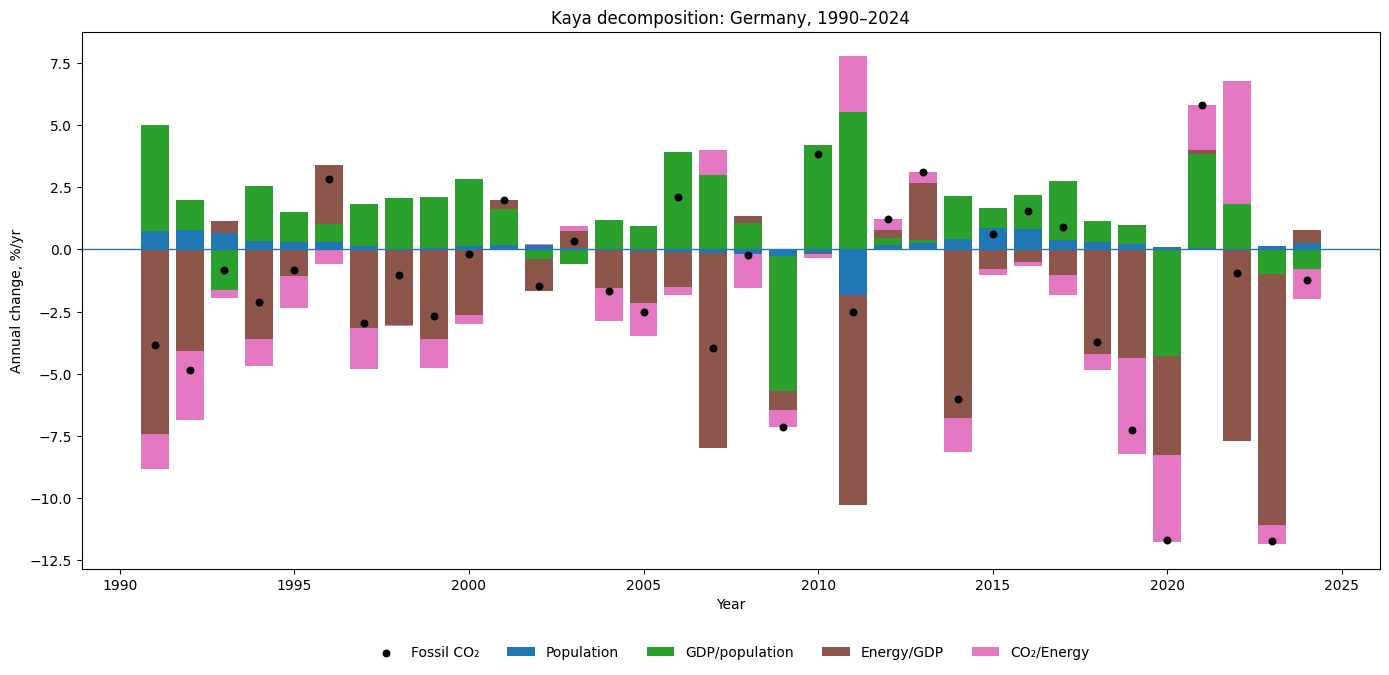

In [117]:
plot = germany_kaya.dropna().copy()

fig, ax = plt.subplots(figsize=(14, 7))

bottom_pos = np.zeros(len(plot))
bottom_neg = np.zeros(len(plot))

components = [
    ("population_pp", "Population", "tab:blue"),
    ("gdp_per_capita_pp", "GDP/population", "tab:green"),
    ("energy_intensity_pp", "Energy/GDP", "tab:brown"),
    ("carbon_intensity_pp", "CO₂/Energy", "tab:pink")
]

for col, label, color in components:
    values = plot[col].values
    pos = np.where(values > 0, values, 0)
    neg = np.where(values < 0, values, 0)

    ax.bar(plot["year"], pos, bottom=bottom_pos, label=label, color=color)
    ax.bar(plot["year"], neg, bottom=bottom_neg, color=color)

    bottom_pos += pos
    bottom_neg += neg

ax.scatter(
    plot["year"],
    plot["co2_growth_pct"],
    color="black",
    s=22,
    label="Fossil CO₂"
)

ax.axhline(0, linewidth=1)

ax.set_title("Kaya decomposition: Germany, 1990–2024")
ax.set_ylabel("Annual change, %/yr")
ax.set_xlabel("Year")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    frameon=False
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)

plt.savefig(
    "germany_kaya_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [118]:
uk.to_csv("uk_full_dataset.csv", index=False)
uk_kaya.to_csv("uk_kaya_1990_2024.csv", index=False)

germany.to_csv("germany_full_dataset.csv", index=False)
germany_kaya.to_csv("germany_kaya_1990_2024.csv", index=False)

In [119]:
from google.colab import files

files.download("uk_full_dataset.csv")
files.download("uk_kaya_1990_2024.csv")

files.download("germany_full_dataset.csv")
files.download("germany_kaya_1990_2024.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>